In [ ]:
import torch
from torchvision import transforms
from PIL import Image, ImageEnhance
import matplotlib.pyplot as plt
import numpy as np
import os

### Routes and devices

In [ ]:
model_path = "../models_trained/efficientnet_finetuned.pth"
label_path = "../models_trained/class_labels.txt"
image_path = "uno/f7.jpg"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
with open(label_path, "r") as f:
    class_names = [line.strip() for line in f.readlines()]

### Model

In [ ]:
from torchvision.models import efficientnet_b0
import torch.nn as nn

def build_model(num_classes):
    model = efficientnet_b0(pretrained=False)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

model = build_model(num_classes=len(class_names))
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

### Image preprocessing

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Imagen
image = Image.open(image_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

### GradCAM function

In [ ]:
def generate_gradcam(model, input_tensor, target_layer="features", class_idx=None):
    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    handle_fw = dict(model.named_modules())[target_layer].register_forward_hook(forward_hook)
    handle_bw = dict(model.named_modules())[target_layer].register_backward_hook(backward_hook)

    output = model(input_tensor)
    if class_idx is None:
        class_idx = output.argmax(dim=1).item()

    model.zero_grad()
    output[0, class_idx].backward()

    grads = gradients[0]
    acts = activations[0]

    pooled_grads = torch.mean(grads, dim=[0, 2, 3])
    for i in range(acts.shape[1]):
        acts[:, i, :, :] *= pooled_grads[i]

    heatmap = acts.mean(dim=1).squeeze()
    heatmap = np.maximum(heatmap.cpu().detach().numpy(), 0)
    heatmap /= np.max(heatmap) + 1e-8

    handle_fw.remove()
    handle_bw.remove()

    return heatmap, class_idx

# Aplying GradCAM
heatmap, pred_idx = generate_gradcam(model, input_tensor)
pred_class = class_names[pred_idx]
print(f"Predicted class: {pred_class}")

### Results visualization

Predicted class: freshbanana


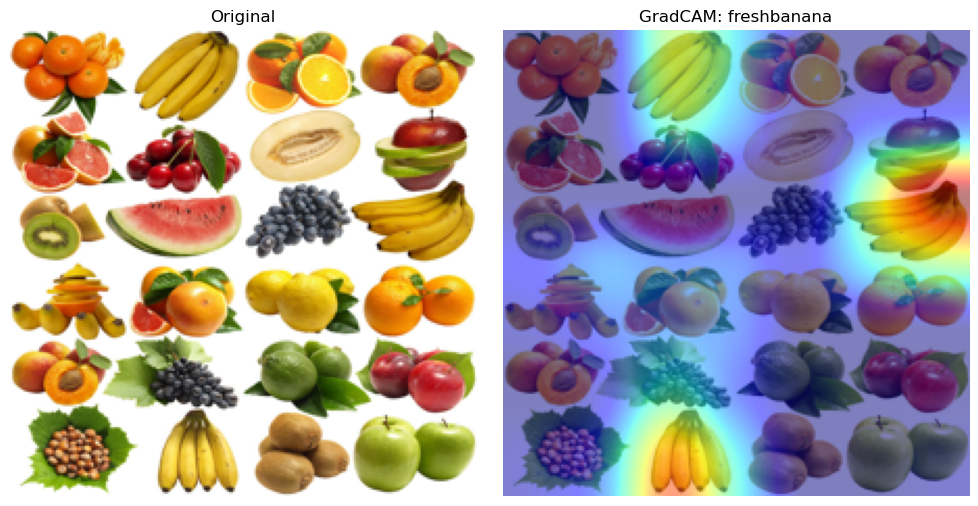

In [7]:
heatmap_img = Image.fromarray(np.uint8(255 * heatmap)).resize((224, 224)).convert("RGB")
colormap = plt.get_cmap("jet")
colored = colormap(np.array(heatmap_img)[:, :, 0] / 255.0)
colored_img = Image.fromarray((colored[:, :, :3] * 255).astype(np.uint8))

image_resized = image.resize((224, 224))
overlay = Image.blend(image_resized, colored_img, alpha=0.5)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(image_resized)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title(f"GradCAM: {pred_class}")
plt.imshow(overlay)
plt.axis("off")
plt.tight_layout()
plt.show()
